# Pre-Processing

### Install libraries & Load the dataset


In [2]:
import os
import glob
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

## Dataset:
The depresjon dataset is a collection of motor activity data token from wrist actigraphy recorded from indivisuals, some are patients ( condition group ) diagnosed with bipolar, unipolar & depression, and some are healthy ( control group ).

The dataset contains 55 files:

23 Condition ( Patients )

32 Control ( Normal )

Scores file containing metadata & clinical / demographic data

In [3]:
SCORES = pd.read_csv("/Depresjon/scores.csv")
CONDITION = glob.glob("/Depresjon/condition/*.csv")
CONTROL = glob.glob("/Depresjon/control/*.csv")

In [4]:
SCORES.head()

,number,days,gender,age,afftype,melanch,inpatient,edu,marriage,work,madrs1,madrs2
0,condition_1,11,2,35-39,2.0,2.0,2.0,6-10,1.0,2.0,19.0,19.0
1,condition_2,18,2,40-44,1.0,2.0,2.0,6-10,2.0,2.0,24.0,11.0
2,condition_3,13,1,45-49,2.0,2.0,2.0,6-10,2.0,2.0,24.0,25.0
3,condition_4,13,2,25-29,2.0,2.0,2.0,11-15,1.0,1.0,20.0,16.0
4,condition_5,13,2,50-54,2.0,2.0,2.0,11-15,2.0,2.0,26.0,26.0


In [5]:
def load_activity():
    frames = []
    for f in CONDITION:
        df = pd.read_csv(f)
        df['number'] = os.path.basename(f).replace(".csv","")
        df['group'] = "condition"
        frames.append(df)

    for f in CONTROL:
        df = pd.read_csv(f)
        df['number'] = os.path.basename(f).replace(".csv","")
        df['group'] = "control"
        frames.append(df)

    return pd.concat(frames, ignore_index=True)

activity = load_activity()
scores = SCORES

activity.head()

,timestamp,date,activity,number,group
0,2005-03-08 10:00:00,2005-03-08,0,condition_12,condition
1,2005-03-08 10:01:00,2005-03-08,0,condition_12,condition
2,2005-03-08 10:02:00,2005-03-08,0,condition_12,condition
3,2005-03-08 10:03:00,2005-03-08,3,condition_12,condition
4,2005-03-08 10:04:00,2005-03-08,0,condition_12,condition


## Date Formating

In [6]:
# Check out the formating of the dates: strict to the same date formats
activity['datetime'] = pd.to_datetime(
    activity['timestamp'],
    format="%Y-%m-%d %H:%M:%S",
    errors='coerce'
)
activity.head()

# Remove Timestamp & Date columns
activity = activity.drop(columns=['timestamp', 'date'])

## Basic Cleaning

In [7]:
# Remove negative activity values
activity_df = activity[
    activity['activity'] >= 0
]

# Sort values by patient and time
activity_df = activity.sort_values(
    ['number', 'datetime']
)

activity_df.head()

,activity,number,group,datetime
43702,0,condition_1,condition,2003-05-07 12:00:00
43703,143,condition_1,condition,2003-05-07 12:01:00
43704,0,condition_1,condition,2003-05-07 12:02:00
43705,20,condition_1,condition,2003-05-07 12:03:00
43706,166,condition_1,condition,2003-05-07 12:04:00


## Signal Smoothing

In [8]:
# Smooth noisy activity signal using moving average

activity_df['activity_smooth'] = (

    activity_df
    .groupby('number')['activity']

    .rolling(window=5)

    .mean()

    .reset_index(level=0, drop=True)

)

# Fill missing values
activity_df['activity_smooth'] = (

    activity_df['activity_smooth']

    .fillna(activity_df['activity'])

)

activity_df.head()

,activity,number,group,datetime,activity_smooth
43702,0,condition_1,condition,2003-05-07 12:00:00,0.0
43703,143,condition_1,condition,2003-05-07 12:01:00,143.0
43704,0,condition_1,condition,2003-05-07 12:02:00,0.0
43705,20,condition_1,condition,2003-05-07 12:03:00,20.0
43706,166,condition_1,condition,2003-05-07 12:04:00,65.8


## Time Features

In [9]:
# Extract hour from datetime

activity_df['hour'] = (
    activity_df['datetime'].dt.hour
)

# Extract date only

activity_df['date'] = (
    activity_df['datetime'].dt.date
)

activity_df.head()

,activity,number,group,datetime,activity_smooth,hour,date
43702,0,condition_1,condition,2003-05-07 12:00:00,0.0,12,2003-05-07
43703,143,condition_1,condition,2003-05-07 12:01:00,143.0,12,2003-05-07
43704,0,condition_1,condition,2003-05-07 12:02:00,0.0,12,2003-05-07
43705,20,condition_1,condition,2003-05-07 12:03:00,20.0,12,2003-05-07
43706,166,condition_1,condition,2003-05-07 12:04:00,65.8,12,2003-05-07


## Rolling Features

In [10]:
for w in [3, 7, 14]:

    activity_df[f'roll_mean_{w}'] = (

        activity_df.groupby('number')['activity_smooth']

        .rolling(w)

        .mean()

        .reset_index(level=0, drop=True)

    )

    activity_df[f'roll_std_{w}'] = (

        activity_df.groupby('number')['activity_smooth']

        .rolling(w)

        .std()

        .reset_index(level=0, drop=True)

    )

## Trend Features

In [11]:
def compute_slope(x):

    if len(x) < 3:
        return 0

    return np.polyfit(
        range(len(x)),
        x,
        1
    )[0]

In [14]:
activity_df['trend_7'] = (

    activity_df.groupby('number')['activity_smooth']

    .rolling(7)

    .apply(compute_slope, raw=False)

    .reset_index(level=0, drop=True)

)

## Night Activity Feature

In [15]:
activity_df['night_activity'] = (

    activity_df['activity_smooth']

    .where(

        (
            activity_df['hour'] >= 22
        ) |
        (
            activity_df['hour'] <= 5
        ),

        0
    )
)

In [16]:
activity_df['night_ratio'] = (

    activity_df.groupby('number')['night_activity']

    .rolling(7)

    .sum()

    .reset_index(level=0, drop=True)

)

## Create Flare-Up Label

In [17]:
activity_df['baseline'] = (

    activity_df.groupby('number')['activity_smooth']

    .rolling(14)

    .mean()

    .reset_index(level=0, drop=True)

)

In [18]:
activity_df['flare_label'] = (

    activity_df['activity_smooth']

    >

    (
        activity_df['baseline'] * 1.5
    )

).astype(int)

## Select Features

In [19]:
features = [

    'roll_mean_7',
    'roll_std_7',

    'roll_mean_14',
    'roll_std_14',

    'trend_7',

    'night_ratio'
]

In [20]:
df_model = activity_df.dropna(
    subset=features + ['flare_label']
)

X = df_model[features]

y = df_model['flare_label']

## Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

## Handle Class Imbalance

In [22]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train,
    y_train
)

## Feature Scaling

In [23]:
scaler = StandardScaler()

X_train_sm = scaler.fit_transform(X_train_sm)

X_test = scaler.transform(X_test)

## Train Model

In [24]:
model = RandomForestClassifier(

    n_estimators=150,

    max_depth=8,

    min_samples_leaf=50,

    class_weight={0:1, 1:3},

    n_jobs=-1,

    random_state=42
)

model.fit(
    X_train_sm,
    y_train_sm
)

RandomForestClassifier(class_weight={0: 1, 1: 3}, max_depth=8,
                       min_samples_leaf=50, n_estimators=150, n_jobs=-1,
                       random_state=42)

## Prediction

In [25]:
y_prob = model.predict_proba(X_test)[:,1]

threshold = 0.30

y_pred = (
    y_prob > threshold
).astype(int)

## Evaluation

In [26]:
print(

    classification_report(
        y_test,
        y_pred
    )

)

              precision    recall  f1-score   support

           0       1.00      0.81      0.89    261338
           1       0.51      0.99      0.68     52861

    accuracy                           0.84    314199
   macro avg       0.76      0.90      0.79    314199
weighted avg       0.92      0.84      0.86    314199



In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[211756  49582]
 [   360  52501]]


In [28]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC:", roc_auc)

ROC AUC: 0.9865066854504008


## Confusion Matrix

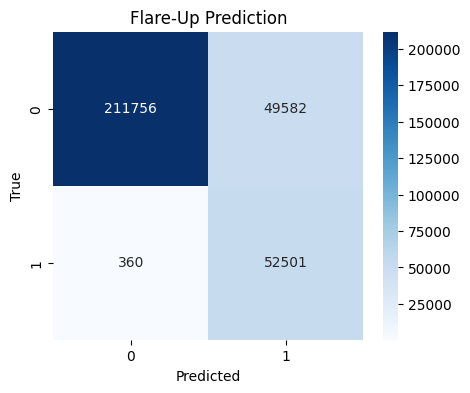

In [29]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.title("Flare-Up Prediction")

plt.show()

## Feature Importance

In [30]:
importance = pd.Series(

    model.feature_importances_,

    index=features

).sort_values(ascending=False)

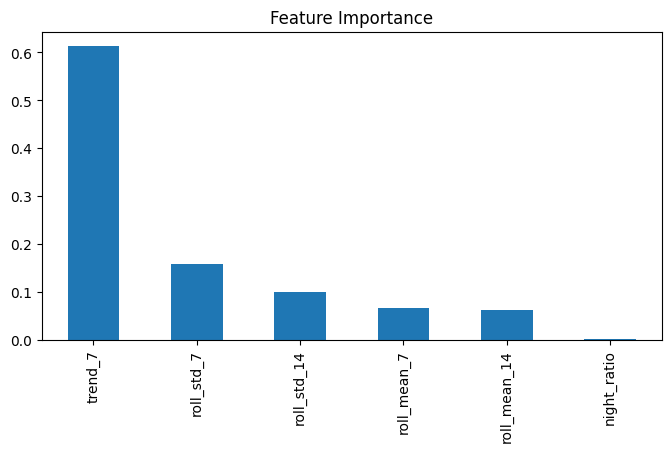

In [31]:
importance.plot(
    kind='bar',
    figsize=(8,4)
)

plt.title("Feature Importance")

plt.show()